# Exploratory Data Analysis

Explore the cleaned dataset to identify patterns, relationships and differences between emotion classes.

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/moodify_clean.csv")

## Emotion Class Distribution

Visualize the distribution of the four emotion classes to identify class imbalance in the dataset.

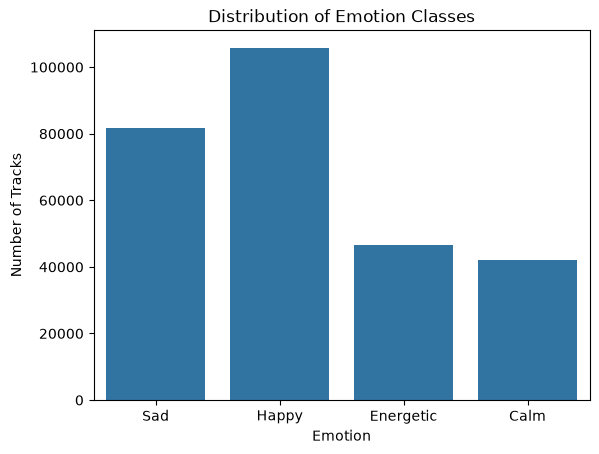

In [28]:
label_names = {
    0: "Sad",
    1: "Happy",
    2: "Energetic",
    3: "Calm"
}

df["emotion"] = df["labels"].map(label_names)

sns.countplot(
    data=df,
    x="emotion",
    order=["Sad", "Happy", "Energetic", "Calm"]
)
plt.title("Distribution of Emotion Classes")
plt.xlabel("Emotion")
plt.ylabel("Number of Tracks")
plt.show()

**Observation:** The dataset is moderately imbalanced. Happy is the largest class, followed by Sad, while Energetic and Calm contain considerably fewer tracks. This imbalance should be considered when evaluating the models.

---

## Energy Across Emotions

Compare the distribution of energy across emotion classes to examine how strongly energy separates the different moods.

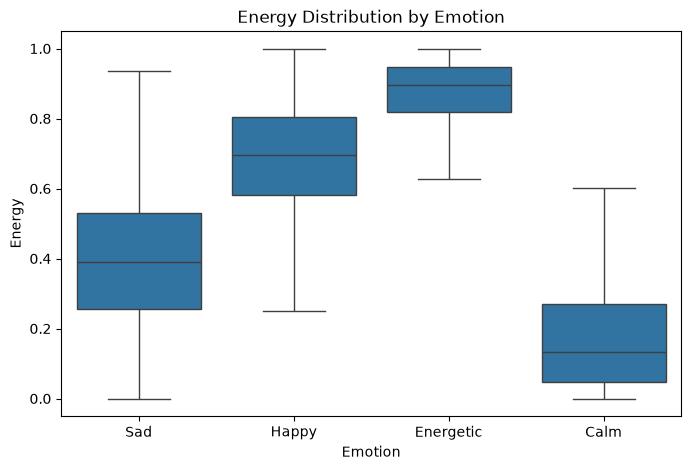

In [29]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="emotion",
    y="energy",
    order=["Sad", "Happy", "Energetic", "Calm"],
    showfliers=False
)

plt.title("Energy Distribution by Emotion")
plt.xlabel("Emotion")
plt.ylabel("Energy")
plt.show()

**Observation:** Energy clearly separates Energetic and Calm tracks. Energetic tracks have consistently high energy, while Calm tracks have much lower energy. Sad shows greater variation and overlaps more with other emotion classes.

---

## Valence Across Emotions

Compare valence across emotion classes to examine differences in the perceived positivity of the music.

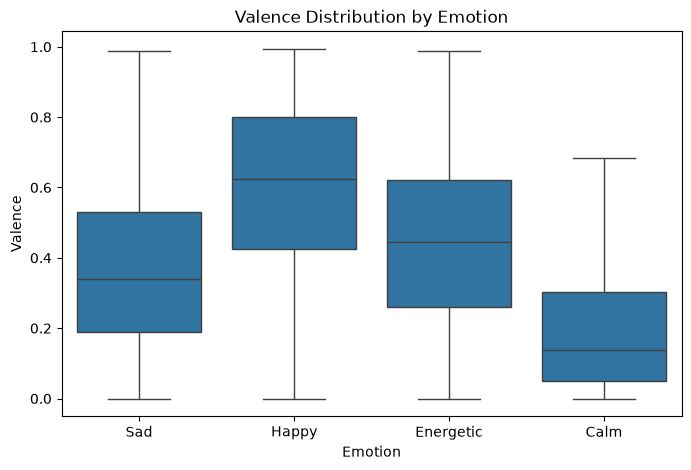

In [30]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="emotion",
    y="valence",
    order=["Sad", "Happy", "Energetic", "Calm"],
    showfliers=False
)

plt.title("Valence Distribution by Emotion")
plt.xlabel("Emotion")
plt.ylabel("Valence")
plt.show()

**Observation:** Happy tracks have the highest median valence, supporting the hypothesis that positive emotion is associated with higher valence. However, the distributions overlap considerably, showing that valence alone is not sufficient to distinguish all emotion classes.

---

## Feature Correlation Analysis

Analyze correlations between numerical audio features to identify strong relationships and potential redundancy between variables.

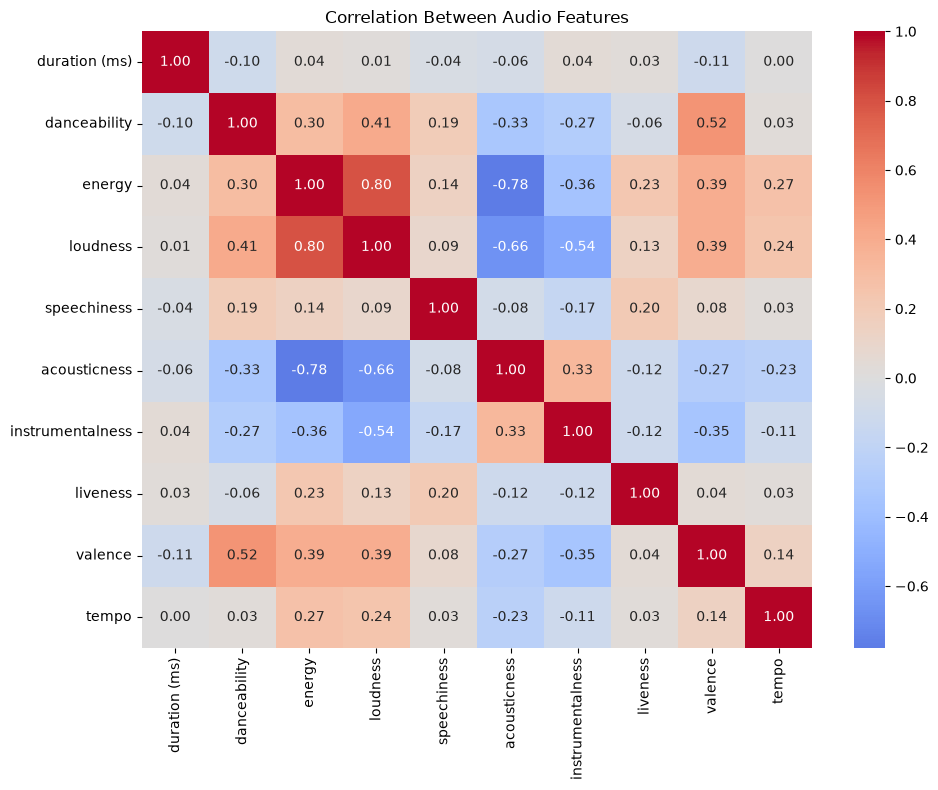

In [31]:
features = df.drop(columns=["labels", "emotion"])

correlation_matrix = features.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Audio Features")
plt.tight_layout()
plt.show()

**Energy ↔ Acousticness = -0,78**  
**Loudness ↔ Acousticness = -0,66**  
**Danceability ↔ Valence = +0,52**  

**Observation:** Energy and loudness show a strong positive correlation (0.80), while energy and acousticness have a strong negative correlation (-0.78). Danceability and valence also show a moderate positive relationship (0.52). Although some features are strongly correlated, they are retained for now to evaluate their contribution during modeling.

---

## Energy and Valence by Emotion

Visualize how emotion classes are distributed across energy and valence simultaneously. A random sample of 5,000 tracks is used to keep the visualization readable.

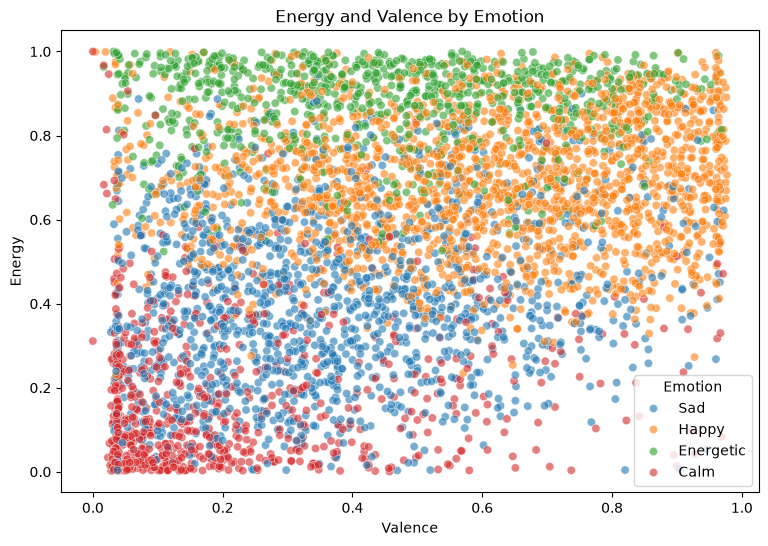

In [32]:
sample_df = df.sample(n=5000, random_state=42)

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=sample_df,
    x="valence",
    y="energy",
    hue="emotion",
    hue_order=["Sad", "Happy", "Energetic", "Calm"],
    alpha=0.6
)

plt.title("Energy and Valence by Emotion")
plt.xlabel("Valence")
plt.ylabel("Energy")
plt.legend(title="Emotion")
plt.show()

**Observation:** The emotion classes form recognizable regions but are not clearly separated using energy and valence alone. Happy overlaps with both Energetic and Sad, while Calm overlaps with Sad. Sad appears particularly dispersed across the feature space, suggesting that its relationship with the other classes may be more complex.

Whether this leads to greater classification difficulty will be evaluated during the machine learning stage.

---

## Statistical Test: Energy Across Emotions

Use the Kruskal-Wallis test to determine whether the distribution of energy differs significantly between the four emotion classes.

In [33]:
from scipy.stats import kruskal

groups = [
    df.loc[df["labels"] == label, "energy"]
    for label in sorted(df["labels"].unique())
]

statistic, p_value = kruskal(*groups)

print("Kruskal-Wallis statistic:", statistic)
print("p-value:", p_value)

Kruskal-Wallis statistic: 183490.46642019192
p-value: 0.0


**Result:** The Kruskal-Wallis test shows a statistically significant difference in energy between the emotion classes (p < 0.05). Together with the boxplot, this provides strong evidence that energy differs meaningfully across the emotion groups.

## Statistical Test: Valence Across Emotions

Use the Kruskal-Wallis test to determine whether the distribution of valence differs significantly between the four emotion classes.

In [34]:
groups = [
    df.loc[df["labels"] == label, "valence"]
    for label in sorted(df["labels"].unique())
]

statistic, p_value = kruskal(*groups)

print("Kruskal-Wallis statistic:", statistic)
print("p-value:", p_value)

Kruskal-Wallis statistic: 74448.53079088977
p-value: 0.0


**Result:** The Kruskal-Wallis test shows a statistically significant difference in valence between the emotion classes (p < 0.05). Together with the boxplot, this provides strong evidence that valence differs meaningfully across the emotion groups.

---

## EDA Summary

- The dataset is moderately imbalanced, with Happy as the largest class and Calm as the smallest.
- Energy clearly differs between emotion classes, especially between Energetic and Calm.
- Happy tracks generally have higher valence, although considerable overlap exists between the classes.
- Energy and loudness are strongly positively correlated, while energy and acousticness are strongly negatively correlated.
- The combination of energy and valence reveals recognizable emotion regions, although considerable overlap remains between several classes.
- Statistical testing confirmed significant differences in both energy and valence across the emotion groups.
- These findings suggest that multiple audio features need to be combined to classify emotion effectively.